# _4.1.3. (binary) classification using Neural Network  (NN)_

This is the main topics of the current notebook. We will focus on applying Artificial Neural Network to the problem of anomaly detection, i.e., separating normal/abnormal samples.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
%matplotlib inline

In [2]:
import seaborn as sns 
import plotly.express as px
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors

In [3]:
import torch
import os

import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [4]:
from xgboost import XGBClassifier
import time
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [5]:
from sklearn import svm, datasets
# import sklearn.model_selection as model_selection

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

In [7]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [8]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag2"

In [9]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

###### (normal vs abnormal)

The basic Idea here is to see the problem as a binary classification problem. 

The population is already devided into _normal_ and _abnormal_

In [10]:
train[target].value_counts(normalize=True)

True     0.746951
False    0.253049
Name: tag2, dtype: float64

#### _c. Split_

In [11]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (45650, 22)
shape(y_train) : (45650,)


#### _d. Check CUDA support_

In [12]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


### _e. (binary) classification using NN_

A neural network is a computational model inspired by the structure and functioning of the human brain. A Neural network is _**trained**_ using data, adjusting the weights based on the difference between predicted and actual outcomes. This process, known as _**backpropagation**_, enables the network to _**learn complex patterns**_ and _**relationships**_ within the data.

In our case, a neural network is trained to categorize instances into two classes, each representing an anomaly or normal behavior. 


<br>

<div style="float: center;"><img  src="docs\pics\binary_nn.png"  alt="binary_nn"  width="450"/>
</div>

</br>

We use **_TensorFlow_**, the free and open-source library, used across a range of tasks but particularly focusing on training and inference of deep neural networks _[[wikipedia]](https://en.wikipedia.org/wiki/TensorFlow)_

In [13]:
# os.environ["CUDA_VISIBLE_DEVICES"]=""
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [14]:
print(tf.__version__)

print('1: ', tf.config.list_physical_devices('GPU'))
print('2: ', tf.test.is_built_with_cuda)
print('3: ', tf.test.gpu_device_name())
print('4: ', tf.config.get_visible_devices())

2.3.0
1:  []
2:  <function is_built_with_cuda at 0x000002B419D844C8>
3:  
4:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [15]:
# Again, Check if TensorFlow is using GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


_**a. Case without dropout layers**_

Here in we will try a simple architecture with no _**dropout**_ layer and lighter _**(32x16)**_ architecture. 

In [16]:
start_time = time.time()

# Define your model
model = models.Sequential()

# Add the input layer and the first hidden layer
model.add(layers.Dense(16, activation='relu', input_shape=(22,)))
# Add more hidden layers if needed
model.add(layers.Dense(8, activation='relu'))

# Output layer with softmax activation for multiclass classification
model.add(layers.Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use categorical_crossentropy if your labels are one-hot encoded
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 16)                368       
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 18        
Total params: 522
Trainable params: 522
Non-trainable params: 0
_________________________________________________________________


In [17]:
# Train the model and store the history
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))

print(f"Training completed in +{(time.time()-start_time)//60:.2f} min.")

Epoch 1/100
1427/1427 [==============================] - 3s 2ms/step - loss: 0.3439 - accuracy: 0.8522 - val_loss: 0.2550 - val_accuracy: 0.9028
Epoch 2/100
1427/1427 [==============================] - 2s 2ms/step - loss: 0.2382 - accuracy: 0.9081 - val_loss: 0.2262 - val_accuracy: 0.9075
Epoch 3/100
1427/1427 [==============================] - 2s 2ms/step - loss: 0.2159 - accuracy: 0.9172 - val_loss: 0.2044 - val_accuracy: 0.9225
Epoch 4/100
1427/1427 [==============================] - 2s 2ms/step - loss: 0.2018 - accuracy: 0.9217 - val_loss: 0.2028 - val_accuracy: 0.9225
Epoch 5/100
1427/1427 [==============================] - 2s 2ms/step - loss: 0.1928 - accuracy: 0.9233 - val_loss: 0.1843 - val_accuracy: 0.9278
Epoch 6/100
1427/1427 [==============================] - 2s 1ms/step - loss: 0.1823 - accuracy: 0.9270 - val_loss: 0.1901 - val_accuracy: 0.9228
Epoch 7/100
1427/1427 [==============================] - 2s 2ms/step - loss: 0.1734 - accuracy: 0.9319 - val_loss: 0.1706 - val_ac

In [18]:
results = model.evaluate(X_test, y_test)
dict(zip(model.metrics_names, results))

535/535 [==============================] - 1s 1ms/step - loss: 0.1107 - accuracy: 0.9605


{'loss': 0.11072441190481186, 'accuracy': 0.960455596446991}

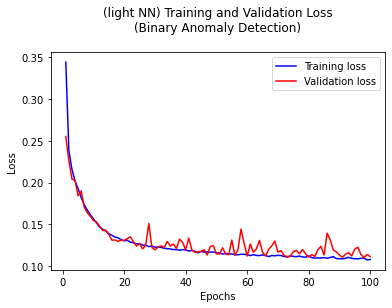

In [19]:
# Extract training and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, c="blue", label='Training loss')
plt.plot(epochs, val_loss, c="red", label='Validation loss')
plt.title('(light NN) Training and Validation Loss\n(Binary Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
# y_pred has shape (9473, 4)
y_vect_pred = model.predict(X_valid)

y_pred = np.argmax(y_vect_pred, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)


# Display a classification report
print("\n(light NN) Classification Report (Binary anomaly detection):\n")
print(classification_report(y_valid, y_pred))


(light NN) Classification Report (Binary anomaly detection):

              precision    recall  f1-score   support

       False       0.93      0.91      0.92      5831
        True       0.97      0.97      0.97     16995

    accuracy                           0.96     22826
   macro avg       0.95      0.94      0.95     22826
weighted avg       0.96      0.96      0.96     22826



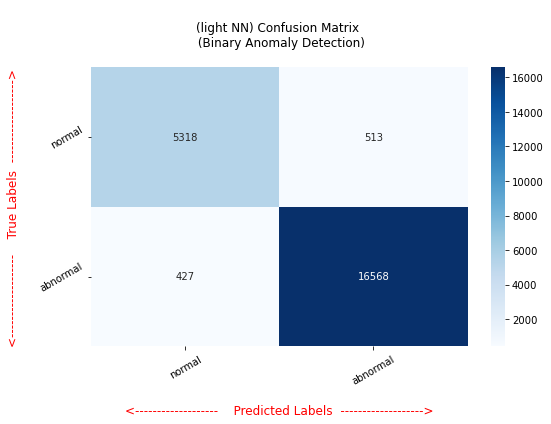

In [21]:
labaled_classes = ['normal','abnormal']
classes = np.unique(y_train) 

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)

plt.title("\n(light NN) Confusion Matrix \n (Binary Anomaly Detection)\n")
plt.tight_layout()
plt.show()

_**b. Case of more complex Architecture**_

Next, we will try more complex architecture with two dropout layers, l2 regularization and a more complex _**(64x32)**_ architecture. 

In [22]:
start_time = time.time()

# Define your model
complex_model = models.Sequential()

# Add the input layer and the first hidden layer
complex_model.add(layers.Dense(64, activation='relu', input_shape=(22,), kernel_regularizer=regularizers.l2(0.01)))
complex_model.add(layers.Dropout(0.5))
# Add more hidden layers if needed
complex_model.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
complex_model.add(layers.Dropout(0.5))

# Output layer with softmax activation for multiclass classification
complex_model.add(layers.Dense(2, activation='softmax'))

# Compile the model
complex_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use categorical_crossentropy if your labels are one-hot encoded
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

complex_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 64)                1472      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_4 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_5 (Dense)              (None, 2)                 66        
Total params: 3,618
Trainable params: 3,618
Non-trainable params: 0
_________________________________________________________________


In [23]:
# Train the model and store the history
history = complex_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))

print(f"Training completed in +{(time.time()-start_time)//60:.2f} min.")

Epoch 1/100
1427/1427 [==============================] - 4s 3ms/step - loss: 0.5978 - accuracy: 0.8055 - val_loss: 0.3635 - val_accuracy: 0.8804
Epoch 2/100
1427/1427 [==============================] - 4s 3ms/step - loss: 0.3718 - accuracy: 0.8639 - val_loss: 0.3223 - val_accuracy: 0.8982
Epoch 3/100
1427/1427 [==============================] - 4s 3ms/step - loss: 0.3498 - accuracy: 0.8738 - val_loss: 0.3169 - val_accuracy: 0.8937
Epoch 4/100
1427/1427 [==============================] - 4s 3ms/step - loss: 0.3424 - accuracy: 0.8749 - val_loss: 0.3008 - val_accuracy: 0.9014
Epoch 5/100
1427/1427 [==============================] - 4s 3ms/step - loss: 0.3345 - accuracy: 0.8772 - val_loss: 0.2911 - val_accuracy: 0.9054
Epoch 6/100
1427/1427 [==============================] - 4s 3ms/step - loss: 0.3297 - accuracy: 0.8786 - val_loss: 0.2866 - val_accuracy: 0.9058
Epoch 7/100
1427/1427 [==============================] - 4s 3ms/step - loss: 0.3261 - accuracy: 0.8786 - val_loss: 0.2838 - val_ac

In [24]:
results = complex_model.evaluate(X_test, y_test)
dict(zip(complex_model.metrics_names, results))

535/535 [==============================] - 1s 2ms/step - loss: 0.2656 - accuracy: 0.9037


{'loss': 0.265606552362442, 'accuracy': 0.9036799073219299}

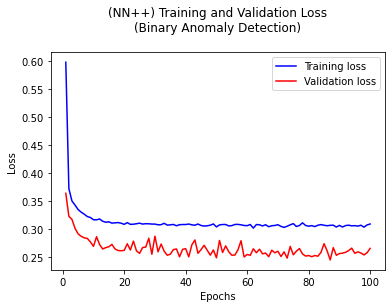

In [25]:
# Extract training and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, c="blue", label='Training loss')
plt.plot(epochs, val_loss, c="red", label='Validation loss')
plt.title('(NN++) Training and Validation Loss\n(Binary Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
# y_pred has shape (9473, 4)
y_vect_pred = complex_model.predict(X_valid)

y_pred = np.argmax(y_vect_pred, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\n(NN) Classification Report (Binary anomaly detection):\n")
print(classification_report(y_valid, y_pred))


(NN) Classification Report (Binary anomaly detection):

              precision    recall  f1-score   support

       False       0.85      0.76      0.80      5831
        True       0.92      0.95      0.94     16995

    accuracy                           0.90     22826
   macro avg       0.88      0.86      0.87     22826
weighted avg       0.90      0.90      0.90     22826



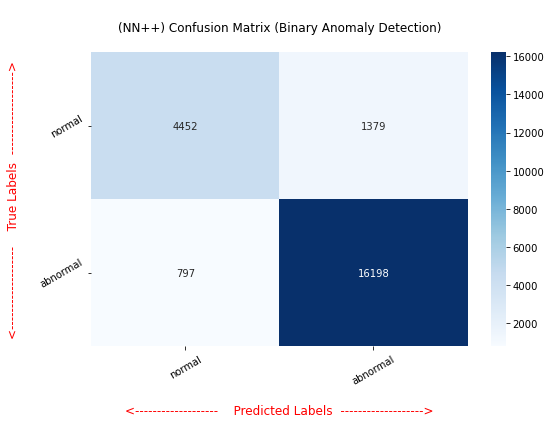

In [27]:
labaled_classes = ['normal','abnormal']
classes = np.unique(y_train) 

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("\n(NN++) Confusion Matrix (Binary Anomaly Detection)\n")
plt.tight_layout()
plt.show()

_**c. Discussion**_

The problem of binary classification in our case, and as we saw in the exploratory data analysis step, is not so complicated. This explain the ability of sapmler architecture to obtain mush better performance then the more complex one. 

Thus, we will pick the sampler variante as a representatif of neural network in our use case.